# LeetCode #108: Convert Sorted Array to Binary Search Tree

https://leetcode.com/problems/convert-sorted-array-to-binary-search-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Always pick left mid | O(n) | O(log n) | Valid but slightly left-heavy |
| **Divide and Conquer (mid as root) ★** | **O(n)** | **O(log n)** | Height-balanced, cleanest |

---

## Understanding the Methods

### Brute Force
Insert each element one by one into a BST. O(n log n) time, not height-balanced.

### Divide and Conquer (Optimal ★)
Since the array is sorted, picking the middle element as root guarantees equal-sized subtrees → height-balanced. Recurse on `nums[lo..mid-1]` for left and `nums[mid+1..hi]` for right. Each of n elements is visited once → O(n). Recursion depth = O(log n).

## Constraints
- 1 ≤ nums.length ≤ 10⁴
- -10⁴ ≤ nums[i] ≤ 10⁴
- nums is sorted in strictly increasing order

## Solutions

### C#

In [ ]:
public class Solution {
    public TreeNode SortedArrayToBST(int[] nums) {
        return Build(nums, 0, nums.Length - 1);
    }

    private TreeNode Build(int[] nums, int lo, int hi) {
        if (lo > hi) return null;
        int mid      = (lo + hi) / 2;
        var node     = new TreeNode(nums[mid]);
        node.left    = Build(nums, lo,      mid - 1);
        node.right   = Build(nums, mid + 1, hi);
        return node;
    }
}

### Python

In [ ]:
class Solution:
    def sortedArrayToBST(self, nums: list[int]):
        def build(lo, hi):
            if lo > hi: return None
            mid        = (lo + hi) // 2
            node       = TreeNode(nums[mid])
            node.left  = build(lo, mid - 1)
            node.right = build(mid + 1, hi)
            return node
        return build(0, len(nums) - 1)

### Go

In [ ]:
func sortedArrayToBST(nums []int) *TreeNode {
    var build func(lo, hi int) *TreeNode
    build = func(lo, hi int) *TreeNode {
        if lo > hi { return nil }
        mid        := (lo + hi) / 2
        node       := &TreeNode{Val: nums[mid]}
        node.Left   = build(lo, mid-1)
        node.Right  = build(mid+1, hi)
        return node
    }
    return build(0, len(nums)-1)
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn sorted_array_to_bst(nums: Vec<i32>) -> Option<Rc<RefCell<TreeNode>>> {
        fn build(nums: &[i32], lo: usize, hi: usize) -> Option<Rc<RefCell<TreeNode>>> {
            if lo > hi { return None; }
            let mid  = (lo + hi) / 2;
            let node = Rc::new(RefCell::new(TreeNode::new(nums[mid])));
            if mid > lo {
                node.borrow_mut().left  = build(nums, lo,      mid - 1);
            }
            node.borrow_mut().right = build(nums, mid + 1, hi);
            Some(node)
        }
        let n = nums.len();
        if n == 0 { return None; }
        build(&nums, 0, n - 1)
    }
}

## Example Scenarios

### 1. Common Case — 5-Element Sorted Array
**Input:** `nums = [-10, -3, 0, 5, 9]`

mid = (0+4)/2 = 2, root = 0. Left: [-10, -3], mid=0, root=-10, right child=-3. Right: [5, 9], mid=3, root=5, right child=9. Height-balanced BST, depth 3.

*Why tricky:* Baseline. Picking the middle guarantees $|leftSize - rightSize| \leq 1$, achieving height balance. Negatives confirm no sign-related index issues.

$mid = \lfloor(lo + hi)/2\rfloor$, balance guaranteed

**Output:** `[0, -10, 5, null, -3, null, 9]`

### 2. Slightly Complex — Even-Length Array (6 Elements)
**Input:** `nums = [1, 2, 3, 4, 5, 6]`

mid = (0+5)/2 = 2, root = 3. Left: [1,2] → root=1, right=2. Right: [4,5,6] → root=5, left=4, right=6. Subtrees differ by 1 in size (2 vs 3) — valid balance.

*Why tricky:* Even length means floor division picks left-of-center mid, slightly favoring the right subtree. An off-by-one in mid calculation would break the height-balance guarantee.

$|S_L| = 2, |S_R| = 3$, $||S_L| - |S_R|| = 1 \leq 1$ ✔

**Output:** `[3, 1, 5, null, 2, 4, 6]`

### 3. Edge Case: Time Factor — 10000 Elements (Maximum)
**Input:** `nums = [-10000, -9999, ..., -1, 0]` (10001 elements near max constraint)

Each element is visited exactly once. Recursion depth = $\lceil\log_2(10001)\rceil = 14$. Each call does $O(1)$ work (array index). Total: $O(n) = O(10001)$.

*Why tricky:* Near max constraint. All negative values. Mid computation $(lo+hi)/2$ is safe from overflow since $lo, hi < 10^4$. Tree has ~14 levels.

$T = O(n)$, each element touched once

**Output:** `balanced BST, root = nums[5000], depth 14`

### 4. Edge Case: Space Factor — Recursion Stack Only
**Input:** `nums = [1, 2, ..., 10000]`

No HashMap, no auxiliary array. Only recursion stack: $O(\log n) \approx 14$ frames. Each frame stores lo, hi, mid — constant. Much better than #105/#106 which need $O(n)$ HashMap.

*Why tricky:* Auxiliary space = $O(\log n)$ — the sorted array provides $O(1)$ random access, eliminating any lookup structure. Contrast with #105's $O(n)$ HashMap requirement.

$S_{aux} = O(\log n) \approx 14$ (no HashMap needed)

**Output:** `balanced BST, depth 14`

### 5. Almost-Impossible but Plausible — Two Elements at Extreme Boundaries
**Input:** `nums = [-10000, 10000]`

mid = (0+1)/2 = 0, root = -10000. Left: lo=0, hi=-1 → null. Right: lo=1, hi=1 → root=10000 (leaf). Result: -10000 as root with right child 10000.

*Why tricky:* $n = 2$ with extreme boundary values $\pm 10^4$. Floor division picks left element as root. Ceiling division would pick right — both valid. Tests the edge of the $lo > hi$ base case.

$\lfloor(0+1)/2\rfloor = 0 \implies$ root = nums[0]

**Output:** `[-10000, null, 10000]`

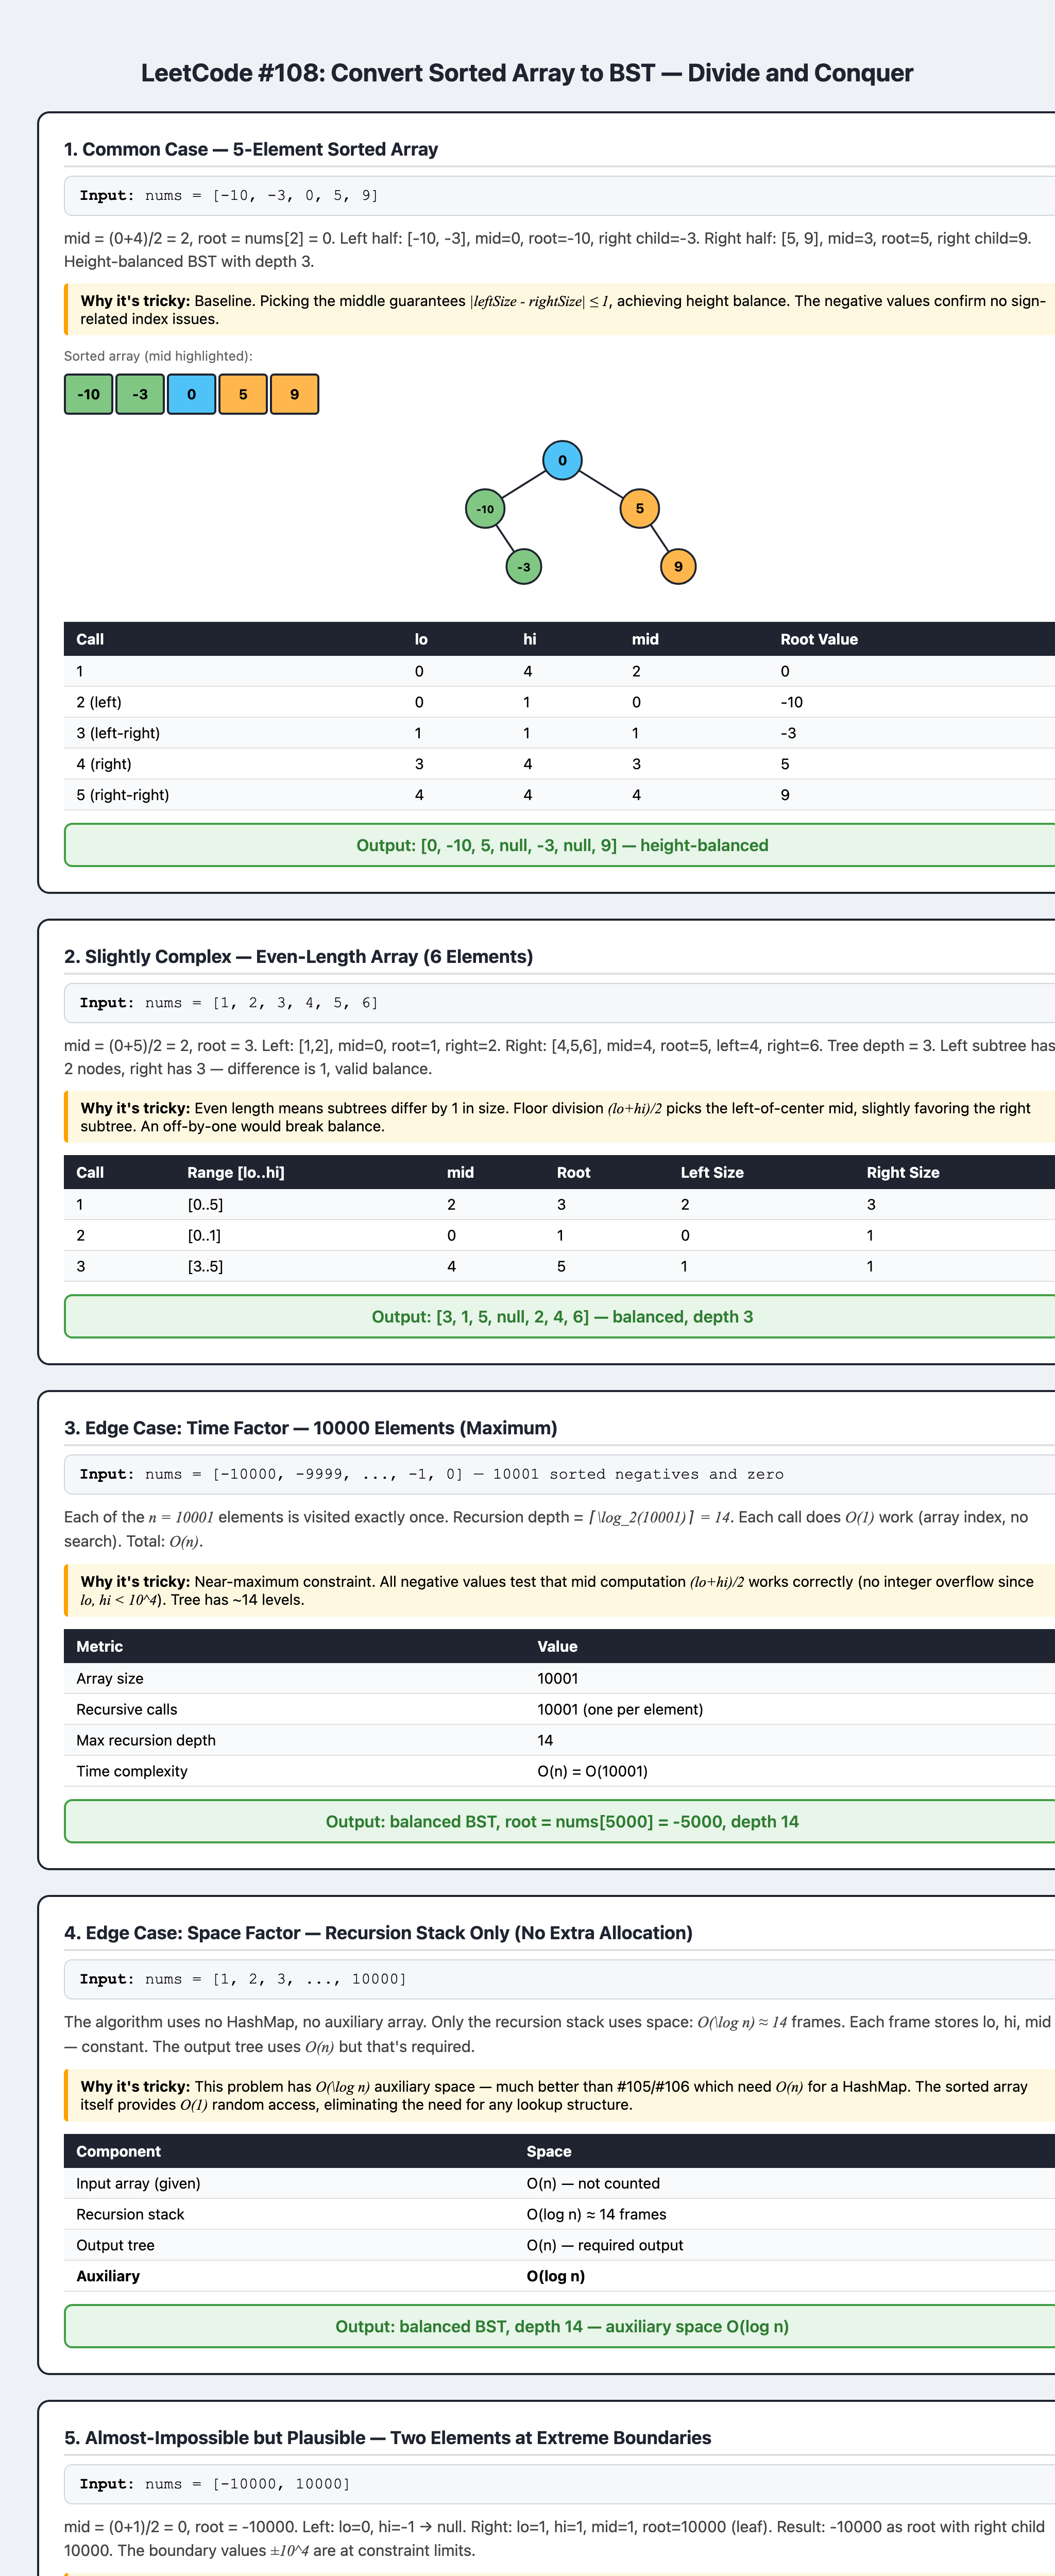